# 02_EDA_and_engineering.ipynb

This is the second notebook of the project, focused on exploratory data analysis (EDA) and feature engineering.

The analysis includes variable definition and semantic interpretation, feature distribution, and data integrity checks

## 1. Imports

As best practice, used libraries are imported before anything else, along with our working clean dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/cleaned.csv")

df.head()

,LIMIT_BAL,PAY_SEP,PAY_AUG,PAY_JUL,PAY_JUN,PAY_MAY,PAY_APR,BILL_AMTSEP,BILL_AMTAUG,BILL_AMTJUL,BILL_AMTJUN,BILL_AMTMAY,BILL_AMTAPR,PAY_AMTSEP,PAY_AMTAUG,PAY_AMTJUL,PAY_AMTJUN,PAY_AMTMAY,PAY_AMTAPR,IS_DEFAULT
0,620.0,2,2,-1,-1,-2,-2,121.303,96.162,21.359,0.000,0.000,0.000,0.000,21.359,0.0,0.0,0.000,0.000,1
1,3720.0,-1,2,0,0,0,2,83.142,53.475,83.142,101.432,107.105,101.091,0.000,31.000,31.0,31.0,0.000,62.000,1
2,2790.0,0,0,0,0,0,0,906.409,434.837,420.329,444.261,463.388,482.019,47.058,46.500,31.0,31.0,31.000,155.000,0
3,1550.0,0,0,0,0,0,0,1456.690,1495.223,1528.021,877.734,897.729,915.957,62.000,62.589,37.2,34.1,33.139,31.000,0
4,1550.0,-1,0,-1,0,0,0,267.127,175.770,1110.885,649.140,593.526,593.061,62.000,1137.111,310.0,279.0,21.359,21.049,0


And as in `01_Extracting_and_cleaning.ipynb`, input and target columns are divided as follows

In [3]:
input_cols = ["LIMIT_BAL"] + \
             [f"PAY_{m}" for m in ["SEP","AUG","JUL","JUN","MAY","APR"]] + \
             [f"BILL_AMT{m}" for m in ["SEP","AUG","JUL","JUN","MAY","APR"]] + \
             [f"PAY_AMT{m}" for m in ["SEP","AUG","JUL","JUN","MAY","APR"]]

target_col = "IS_DEFAULT"

## 2. Feature interpretation

Here is a brief description of every column with its meaning, possible values and interpretations (as per the UCI Machine Learning Repository documentation):
- `LIMIT_BAL`: maximum credit limit assigned to the client (in USD), continuous positive variable
- `PAY_SEP` – `PAY_APR`: monthly repayment status indicators, ordinal variables where negative values indicate early payment (-2 = not used, -1 = paid full on time), 0 indicates use of revolving credit, and positive values indicate increasing months of delay
- `BILL_AMTSEP` – `BILL_AMTAPR`: monthly billed amount (in USD), continuous variables representing billed credit amount for each client at the end of the month (negative values indicate credit on the client)
- `PAY_AMTSEP` – `PAY_AMTAPR`: monthly payment amount (in USD), continuous variables representing actual repayments for the previous month, continuous positive variable
- `IS_DEFAULT`: binary target variable indicating default in the next month, where 1 = default and 0 = non-default

After having defined all of our working columns, value ranges are analyzed to spot any inconsistencies

In [4]:
pd.set_option('display.max_columns', None) # Show all columns in the output

df.describe()

,LIMIT_BAL,PAY_SEP,PAY_AUG,PAY_JUL,PAY_JUN,PAY_MAY,PAY_APR,BILL_AMTSEP,BILL_AMTAUG,BILL_AMTJUL,BILL_AMTJUN,BILL_AMTMAY,BILL_AMTAPR,PAY_AMTSEP,PAY_AMTAUG,PAY_AMTJUL,PAY_AMTJUN,PAY_AMTMAY,PAY_AMTAPR,IS_DEFAULT
count,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000
mean,5190.702155,-0.016753,-0.131854,-0.164392,-0.218922,-0.264509,-0.289438,1589.773303,1526.327355,1459.105398,1342.713226,1251.108366,1206.427381,175.773079,183.767479,162.182354,149.780141,148.951808,161.866438,0.221258
std,4022.564192,1.123492,1.196322,1.195878,1.168175,1.132220,1.149090,2283.402105,2207.062589,2150.511922,1994.958946,1885.331049,1846.798580,513.727333,714.657156,546.107195,485.908401,473.877541,551.396283,0.415101
min,310.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-5132.980000,-2163.087000,-4875.184000,-5270.000000,-2521.354000,-10527.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1550.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,111.445000,93.310000,84.041000,73.160000,55.397000,39.122000,31.000000,26.350000,12.090000,9.300000,8.091000,4.061000,0.000000
50%,4340.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,695.578000,660.145000,624.185000,591.511000,562.030000,530.844000,65.162000,62.310000,55.924000,46.500000,46.500000,46.500000,0.000000
75%,7440.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2085.060000,1987.379000,1866.231000,1692.631000,1557.657000,1526.812000,155.248000,155.000000,139.872000,124.496000,125.302000,124.000000,0.000000
max,31000.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,29899.841000,30501.861000,51586.759000,27639.166000,28742.301000,29811.584000,27080.112000,52212.029000,27777.240000,19251.000000,13222.399000,16388.646000,1.000000


## 3. First EDA

No inconsistent or missing values are present in the dataset, therefore a first Exploratory Data Analysis (EDA) is performed. The analysis focuses on:
- Target class distribution analysis
- Per-feature distribution analysis
- Mean feature value comparison across target classes
- Correlation heatmap between input features

Default rate: 22.13%


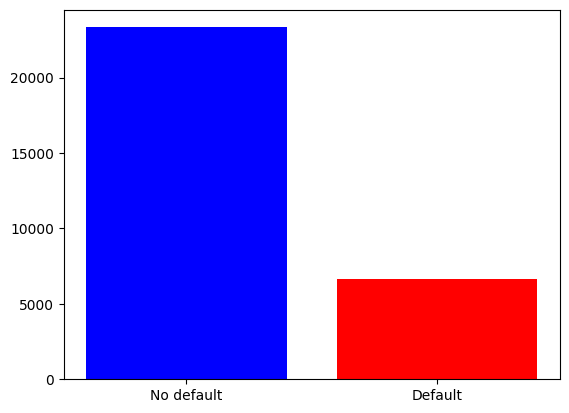

In [5]:
### TARGET CLASS DISTRIBUTION

print(f"Default rate: {df[target_col].value_counts()[1] / len(df):.2%}")

plt.bar(["No default", "Default"], df[target_col].value_counts(), color=["Blue", "Red"])

plt.show()

Clients who default represent a minority of the total client base; therefore, class imbalance must be explicitly considered during both modeling and feature engineering stages

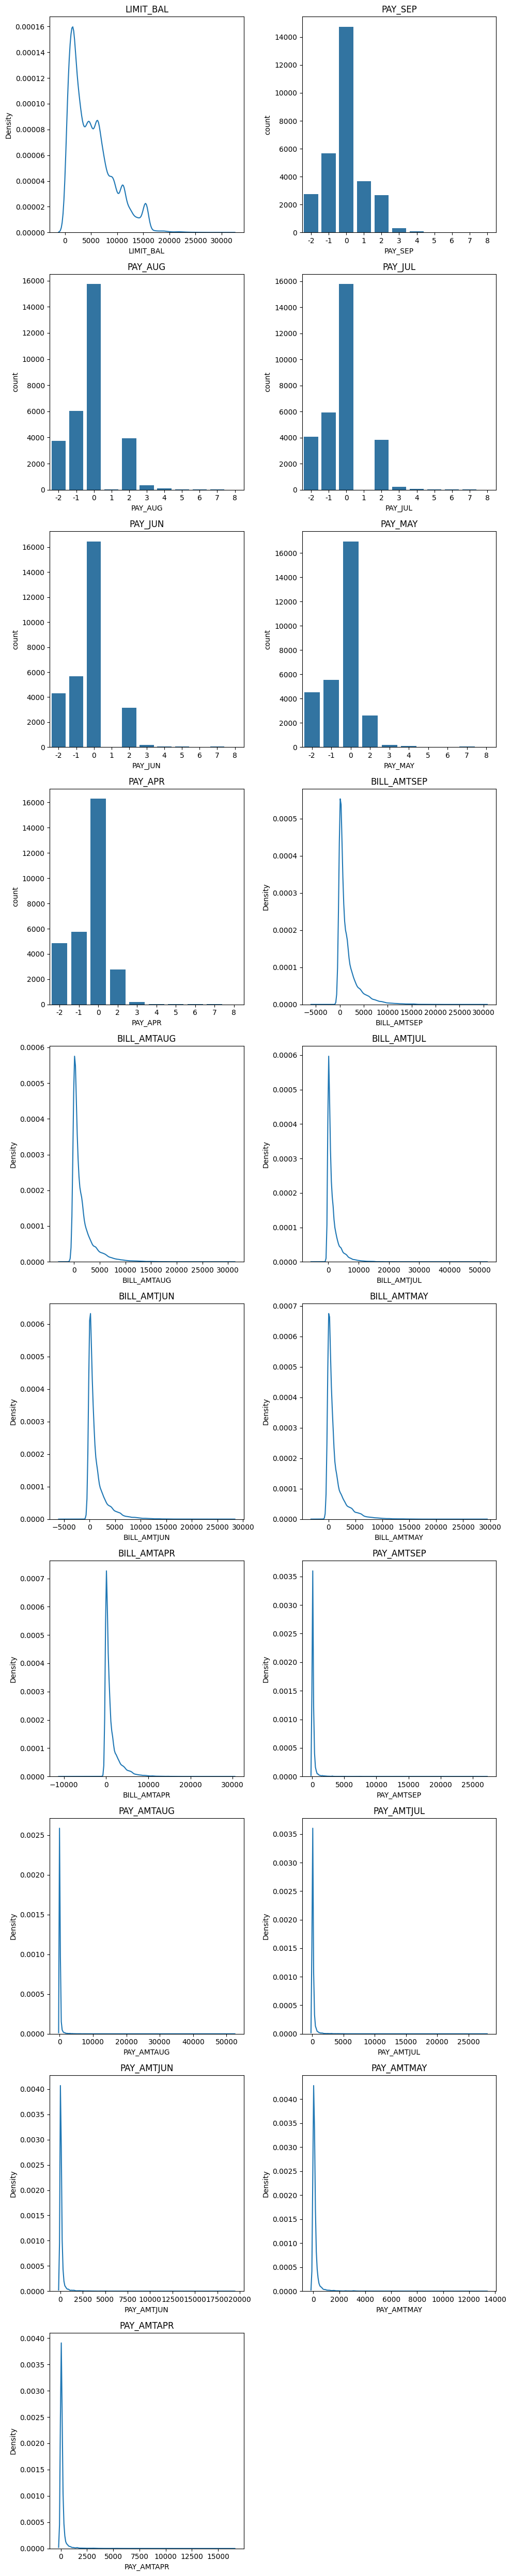

In [6]:
### PER-FEATURE DISTRIBUTION

discrete_cols = [f"PAY_{month}" for month in ["SEP", "AUG", "JUL", "JUN", "MAY", "APR"]]

continuous_cols = ["LIMIT_BAL"] + \
                  [f"BILL_AMT{month}" for month in ["SEP", "AUG", "JUL", "JUN", "MAY", "APR"]] + \
                  [f"PAY_AMT{month}" for month in ["SEP", "AUG", "JUL", "JUN", "MAY", "APR"]]

fig, axes = plt.subplots(10, 2, figsize=(10, 50))
axes = axes.flatten()
plot_idx = 0

for col in input_cols:

    ax = axes[plot_idx]

    if col in continuous_cols: # KDE for continuous features
        sns.kdeplot(data=df, x=col, ax=ax)
    else: # Countplot for discrete features
        sns.countplot(data=df, x=col, ax=ax)

    ax.set_title(col)

    plot_idx += 1

# turn off remaining unused plots
for i in range(plot_idx, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


- `LIMIT_BAL`: highly discretized / step-like distribution, likely due to standardized credit tiers or rounding policies  
- `PAY_AMT*`: strongly right-skewed distributions, indicating a small fraction of clients with very large repayments (high-income outliers)  
- `PAY_*` (repayment status): generally right-skewed toward low delay values  
  - most observations are at 0, -1, -2 
  - values indicating sustained delays are rare, forming a heavy tail  
  - the relatively low frequency of early positive delays (e.g., `1`) may reflect transition dynamics where clients either remain current (0/-1/-2) or rapidly progress to higher delinquency states. Nonetheless, no clear conclusion on this phenomenon can be given

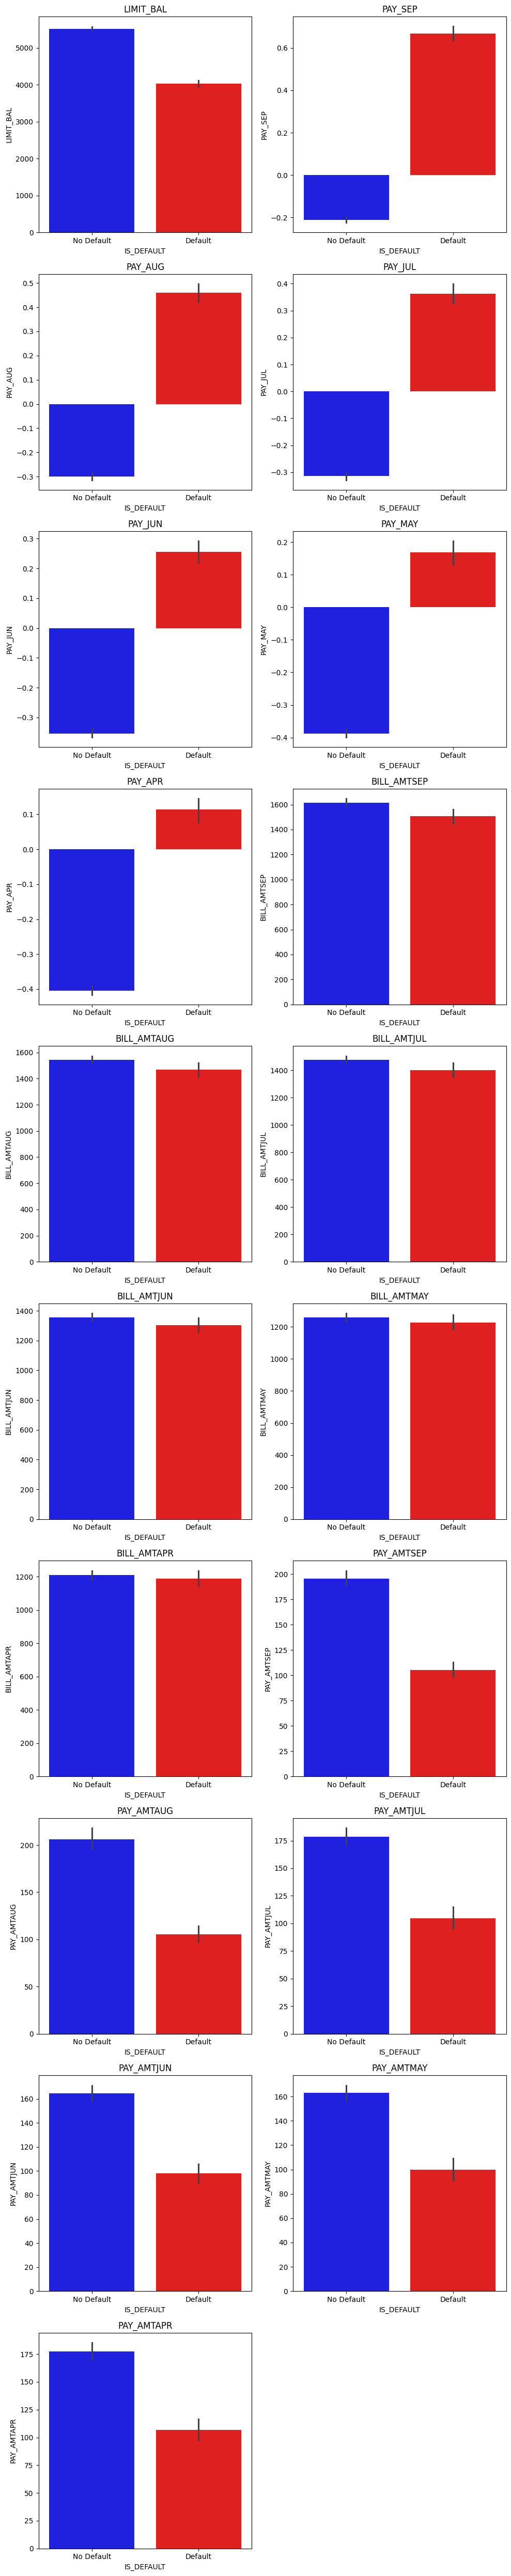

In [7]:
### MEAN FEATURE VALUE ACROSS TARGET CLASSES

fig, axes = plt.subplots(10, 2, figsize=(10, 50))
axes = axes.flatten()
plot_idx = 0

for col in input_cols:

    ax = axes[plot_idx]

    sns.barplot( # barplot for every feature, calculating mean for every target class
        data=df,
        hue=target_col,
        x=target_col,
        y=col,
        estimator="mean",
        ax=ax,
        palette=["blue", "red"],
        legend=False
    )

    ax.set_title(col)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No Default", "Default"])

    plot_idx += 1

# turn off remaining unused plots
for i in range(plot_idx, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

- `PAY_*` (repayment status): clear separation between classes  
  - non-default clients tend to pay on time (0, -1, -2)  
  - default clients show higher frequency of delayed or partial repayment states  
  → strongest discriminative signal in the dataset 

- `BILL_AMT*`:  
  - weak marginal separation
  - may still carry predictive signal through temporal evolution (e.g. delta and trend features)

- `PAY_AMT*`:  
  - higher payments observed in non-defaulting customers  
  - default clients tend to have consistently lower repayment amounts relative to exposure  

- `LIMIT_BAL`:  
  - partially endogenous, as credit limits are likely assigned based on prior risk assessment
  → moderate predictive signal, partly influenced by risk assignment policy  

- **Modeling implication**:  
  - near-linear separability exists, mainly driven by repayment behavior features  
  - linear models (e.g., Logistic Regression) are expected to perform competitively  
  - non-linear models may provide only marginal gains unless other critical features are engineered

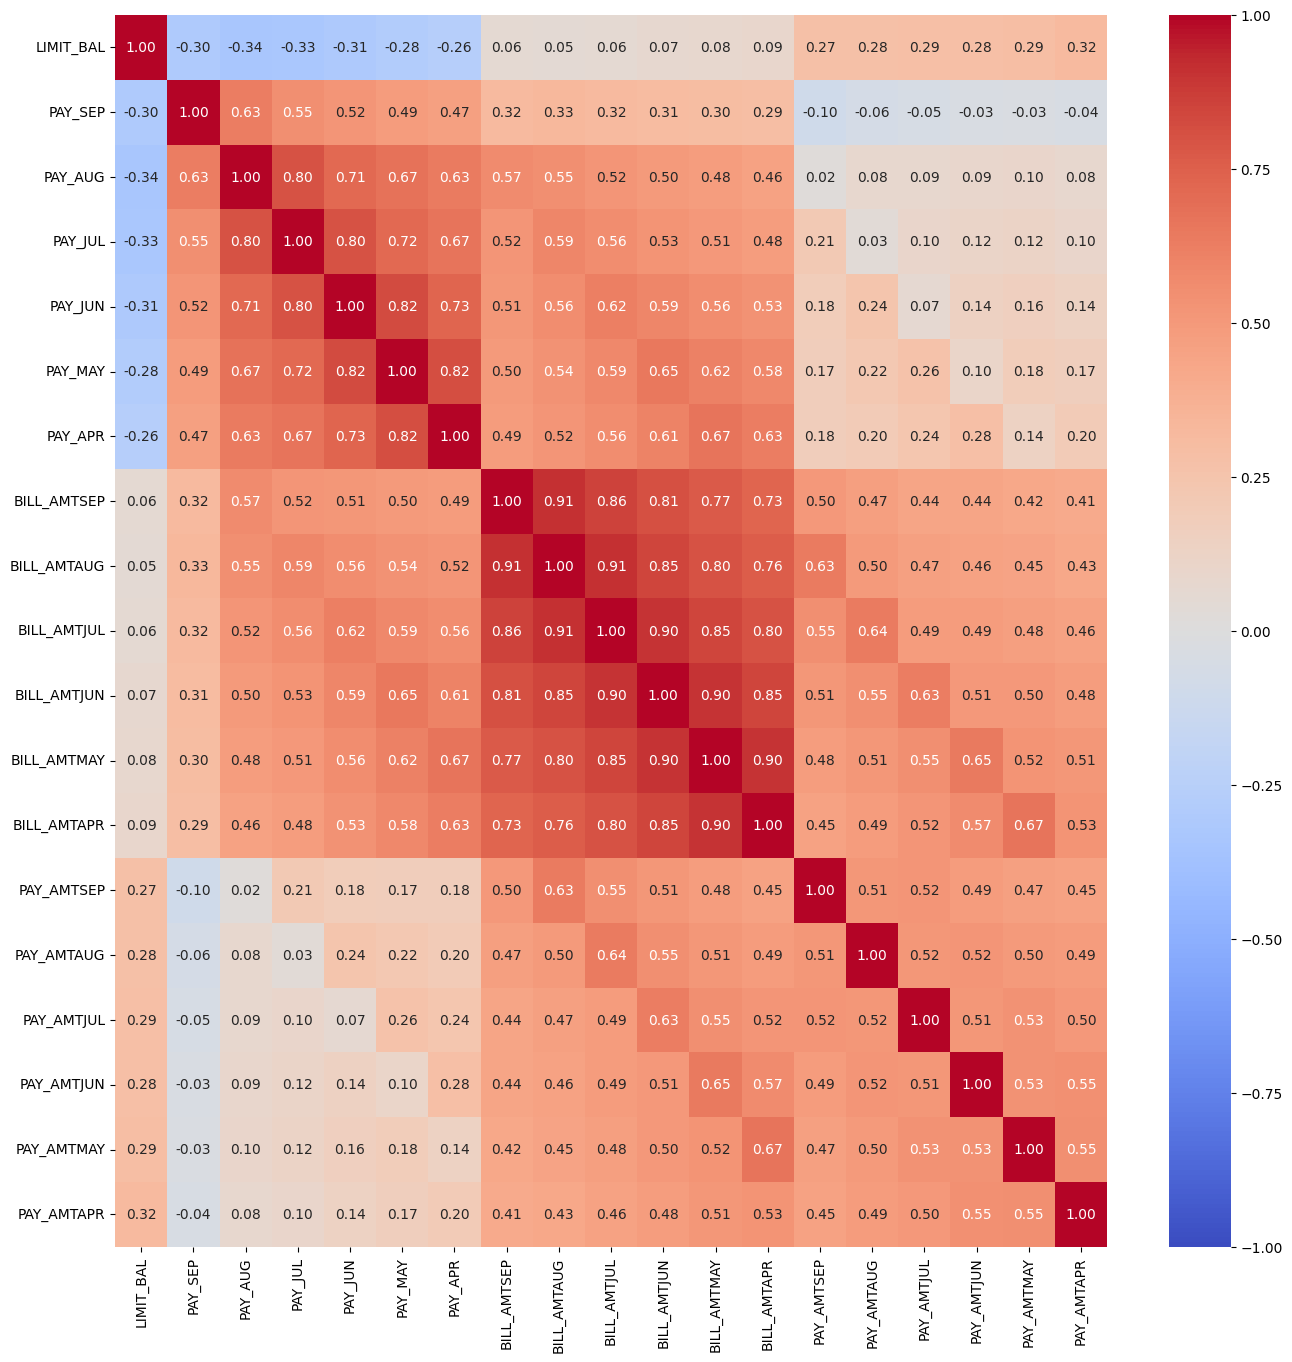

In [8]:
### CORRELATION HEATMAP

plt.figure(figsize=[16,16])

sns.heatmap(df.drop(columns=[target_col]).corr(method="spearman"), cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1) # spearman for skewed distributions and non-linear correlations

plt.show()

- `BILL_AMT*` variables are strongly inter-correlated across close months
  - indicates temporal redundancy rather than independent information  
  - suitable for dimensionality reduction (e.g. PCA or aggregation via mean/trend features)  
  - benefit: reduced multicollinearity and lower feature dimensionality with minimal information loss  

- `PAY_*` vs `BILL_AMT*` and `PAY_AMT*` vs `BILL_AMT*`:  
  - correlations are moderate (typically ≤ 0.7)  
  - reflects behavioral linkage but not redundancy  
  - not suitable for aggressive dimensionality reduction  
  - each group captures different aspects of credit behavior (status vs exposure vs repayment capacity)  

- **Modeling implication**:  
  - dimensionality reduction is justified primarily for `BILL_AMT*` (e.g. PCA or engineered aggregates)  
  - other feature groups should be preserved to retain predictive signal diversity

## 4. First Feature engineering

Concluded the first Exploratory Data Analysis (EDA). The following structural changes and feature engineering steps will be applied to the dataset:

*   **Behavioral Feature Engineering:**
    *   **Paid-to-remaining ratios**: Created month-per-month ratios (`PAY_AMT / BILL_AMT`) to capture repayment capacity.
    *   **Credit Utilization**: Created month-per-month ratios (`BILL_AMT / LIMIT_BAL`) to track credit limit exposure over time.
*   **Removal of `BILL_AMT*` columns:** already strongly present in credit utilization (just averaged and multiplied by a constant factor of `1 / LIMIT_BAL`, would create collinearity otherwise)


In [9]:
### BEHAVIORAL FEATURE ENGINEERING

months = ["SEP", "AUG", "JUL", "JUN", "MAY", "APR"]

for m in months: # calculate payment coverage as PAY_AMT / BILL_AMT
    pay_col = f"PAY_AMT{m}"
    bill_col = f"BILL_AMT{m}"
    
    coverage = df[pay_col] / df[bill_col]
    
    # If BILL_AMT > 0, set coverage as defined
    df[f"PAID_TO_REMAINING_{m}"] = coverage.where(df[bill_col] > 0, 1)
    
    # If BILL_AMT <= 0, set coverage = 1 (has repaid in full, avoids +-inf with BILL_AMT* = 0)
    df[f"PAID_TO_REMAINING_{m}"] = df[f"PAID_TO_REMAINING_{m}"].replace([np.inf, -np.inf], 1).fillna(1)

for m in months: # calculate credit utilization as BILL_AMT / LIMIT_BAL
    bill_col = f"BILL_AMT{m}"
    
    df[f"CREDIT_UTIL_{m}"] = df[bill_col] / df["LIMIT_BAL"] # negative values can exist (BILL_AMT < 0) -> not a problem, it indicates credit to the customer


### DIMENSIONALITY REDUCTION on BILL_AMT*

bill_cols = [f"BILL_AMT{month}" for month in ["APR", "MAY", "JUN", "JUL", "AUG", "SEP"]]

df["EAD"] = df["BILL_AMTSEP"] # save for future use, will not be used in training (EAD = Exposure At Default, generally equal to current credit usage)

# Edit dataframe
df = df.drop(columns=bill_cols)

df.head()

,LIMIT_BAL,PAY_SEP,PAY_AUG,PAY_JUL,PAY_JUN,PAY_MAY,PAY_APR,PAY_AMTSEP,PAY_AMTAUG,PAY_AMTJUL,PAY_AMTJUN,PAY_AMTMAY,PAY_AMTAPR,IS_DEFAULT,PAID_TO_REMAINING_SEP,PAID_TO_REMAINING_AUG,PAID_TO_REMAINING_JUL,PAID_TO_REMAINING_JUN,PAID_TO_REMAINING_MAY,PAID_TO_REMAINING_APR,CREDIT_UTIL_SEP,CREDIT_UTIL_AUG,CREDIT_UTIL_JUL,CREDIT_UTIL_JUN,CREDIT_UTIL_MAY,CREDIT_UTIL_APR,EAD
0,620.0,2,2,-1,-1,-2,-2,0.000,21.359,0.0,0.0,0.000,0.000,1,0.000000,0.222115,0.000000,1.000000,1.000000,1.000000,0.195650,0.155100,0.034450,0.000000,0.000000,0.000000,121.303
1,3720.0,-1,2,0,0,0,2,0.000,31.000,31.0,31.0,0.000,62.000,1,0.000000,0.579710,0.372856,0.305623,0.000000,0.613309,0.022350,0.014375,0.022350,0.027267,0.028792,0.027175,83.142
2,2790.0,0,0,0,0,0,0,47.058,46.500,31.0,31.0,31.000,155.000,0,0.051917,0.106937,0.073752,0.069779,0.066899,0.321564,0.324878,0.155856,0.150656,0.159233,0.166089,0.172767,906.409
3,1550.0,0,0,0,0,0,0,62.000,62.589,37.2,34.1,33.139,31.000,0,0.042562,0.041859,0.024345,0.038850,0.036914,0.033844,0.939800,0.964660,0.985820,0.566280,0.579180,0.590940,1456.690
4,1550.0,-1,0,-1,0,0,0,62.000,1137.111,310.0,279.0,21.359,21.049,0,0.232099,6.469312,0.279057,0.429799,0.035987,0.035492,0.172340,0.113400,0.716700,0.418800,0.382920,0.382620,267.127


## 5. Second EDA (localized)

After having engineered the new variables (`PAID_TO_REMAINING_*`, `CREDIT_UTIL_*`), a second localized Exploratory Data Analysis (EDA) is performed, with the same focuses as before:
- Per-feature distribution analysis
- Mean feature value comparison across target classes
- Correlation heatmap between input features

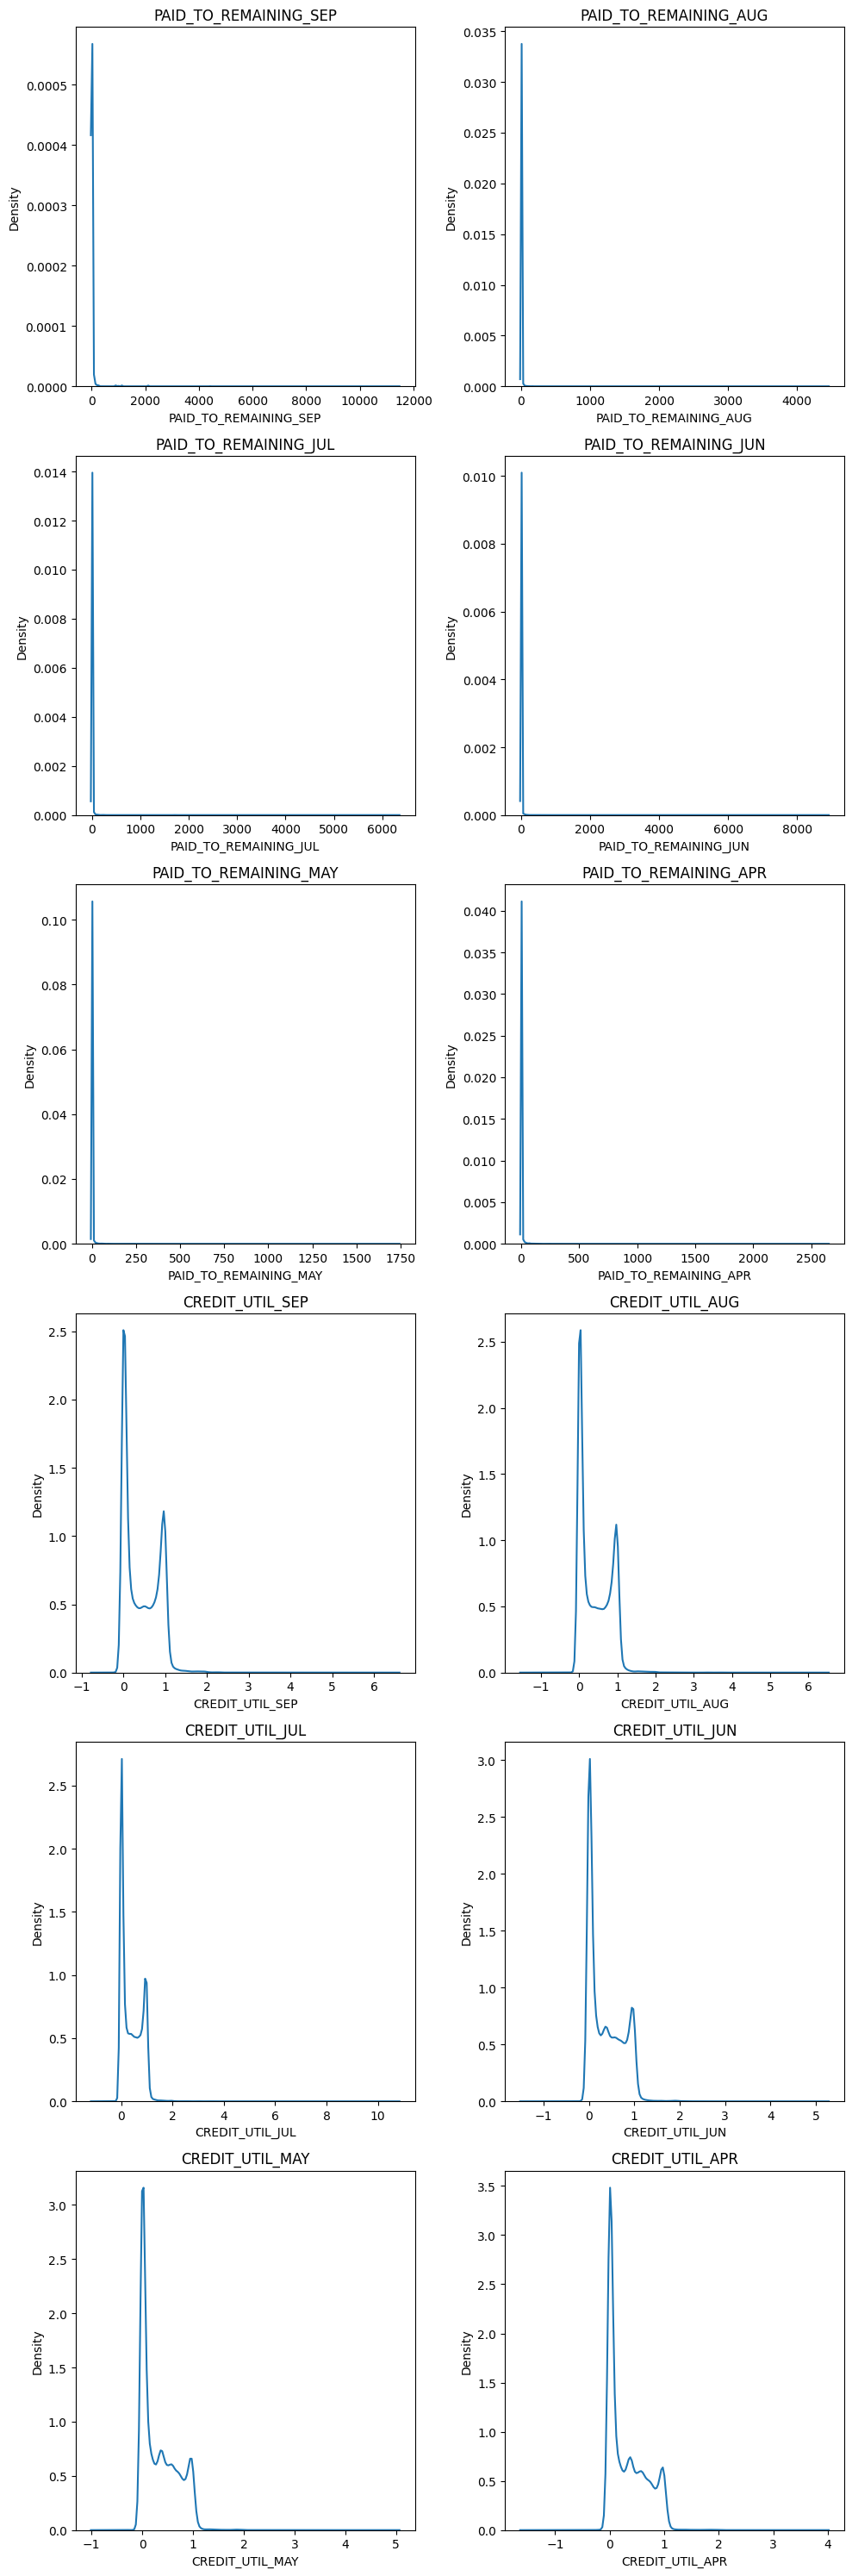

In [10]:
### PER-FEATURE DISTRIBUTION

discrete_cols = []

continuous_cols = [f"PAID_TO_REMAINING_{month}" for month in ["SEP", "AUG", "JUL", "JUN", "MAY", "APR"]] + \
                  [f"CREDIT_UTIL_{month}" for month in ["SEP", "AUG", "JUL", "JUN", "MAY", "APR"]]

input_cols = discrete_cols + continuous_cols

fig, axes = plt.subplots(6, 2, figsize=(10, 30))
axes = axes.flatten()
plot_idx = 0

for col in input_cols:

    ax = axes[plot_idx]

    if col in continuous_cols: # KDE for continuous features
        sns.kdeplot(data=df, x=col, ax=ax)
    else: # Countplot for discrete features
        sns.countplot(data=df, x=col, ax=ax)

    ax.set_title(col)

    plot_idx += 1

# turn off remaining unused plots
for i in range(plot_idx, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


* `PAID_TO_REMAINING_*` extreme right-skewed distribution with a heavy tail stretching well beyond $1.0$. In credit operations, values significantly greater than 1 occur when clients settle amounts larger than their current monthly billed statements (`PAY_AMT` > `BILL_AMT`). This phenomenon stems from proactive financial behaviors, such as clearing unmapped previous dues, overpaying to reload the credit line for upcoming major transactions, or highly conservative liquidity management. These extreme positive outliers represent an exceptionally strong non-default signal.

* `CREDIT_UTIL_*` distinctly bimodal distribution, clustering around $0.0$ (dormant/low utilization) and $1.0$ (maximum capacity saturation). Financially, this metric serves as a high-fidelity proxy for credit distress. While a cluster near 0 reflects safe, transactional card usage backed by ample financial buffers, a cluster near or exceeding 1.0 captures "revolving trap" dynamics where clients consistently exhaust their credit limits or see their balances artificially inflated by compounded interest fees and late penalties. This structural split provides a massive discriminative signal for separating solvent profiles from impending defaults.

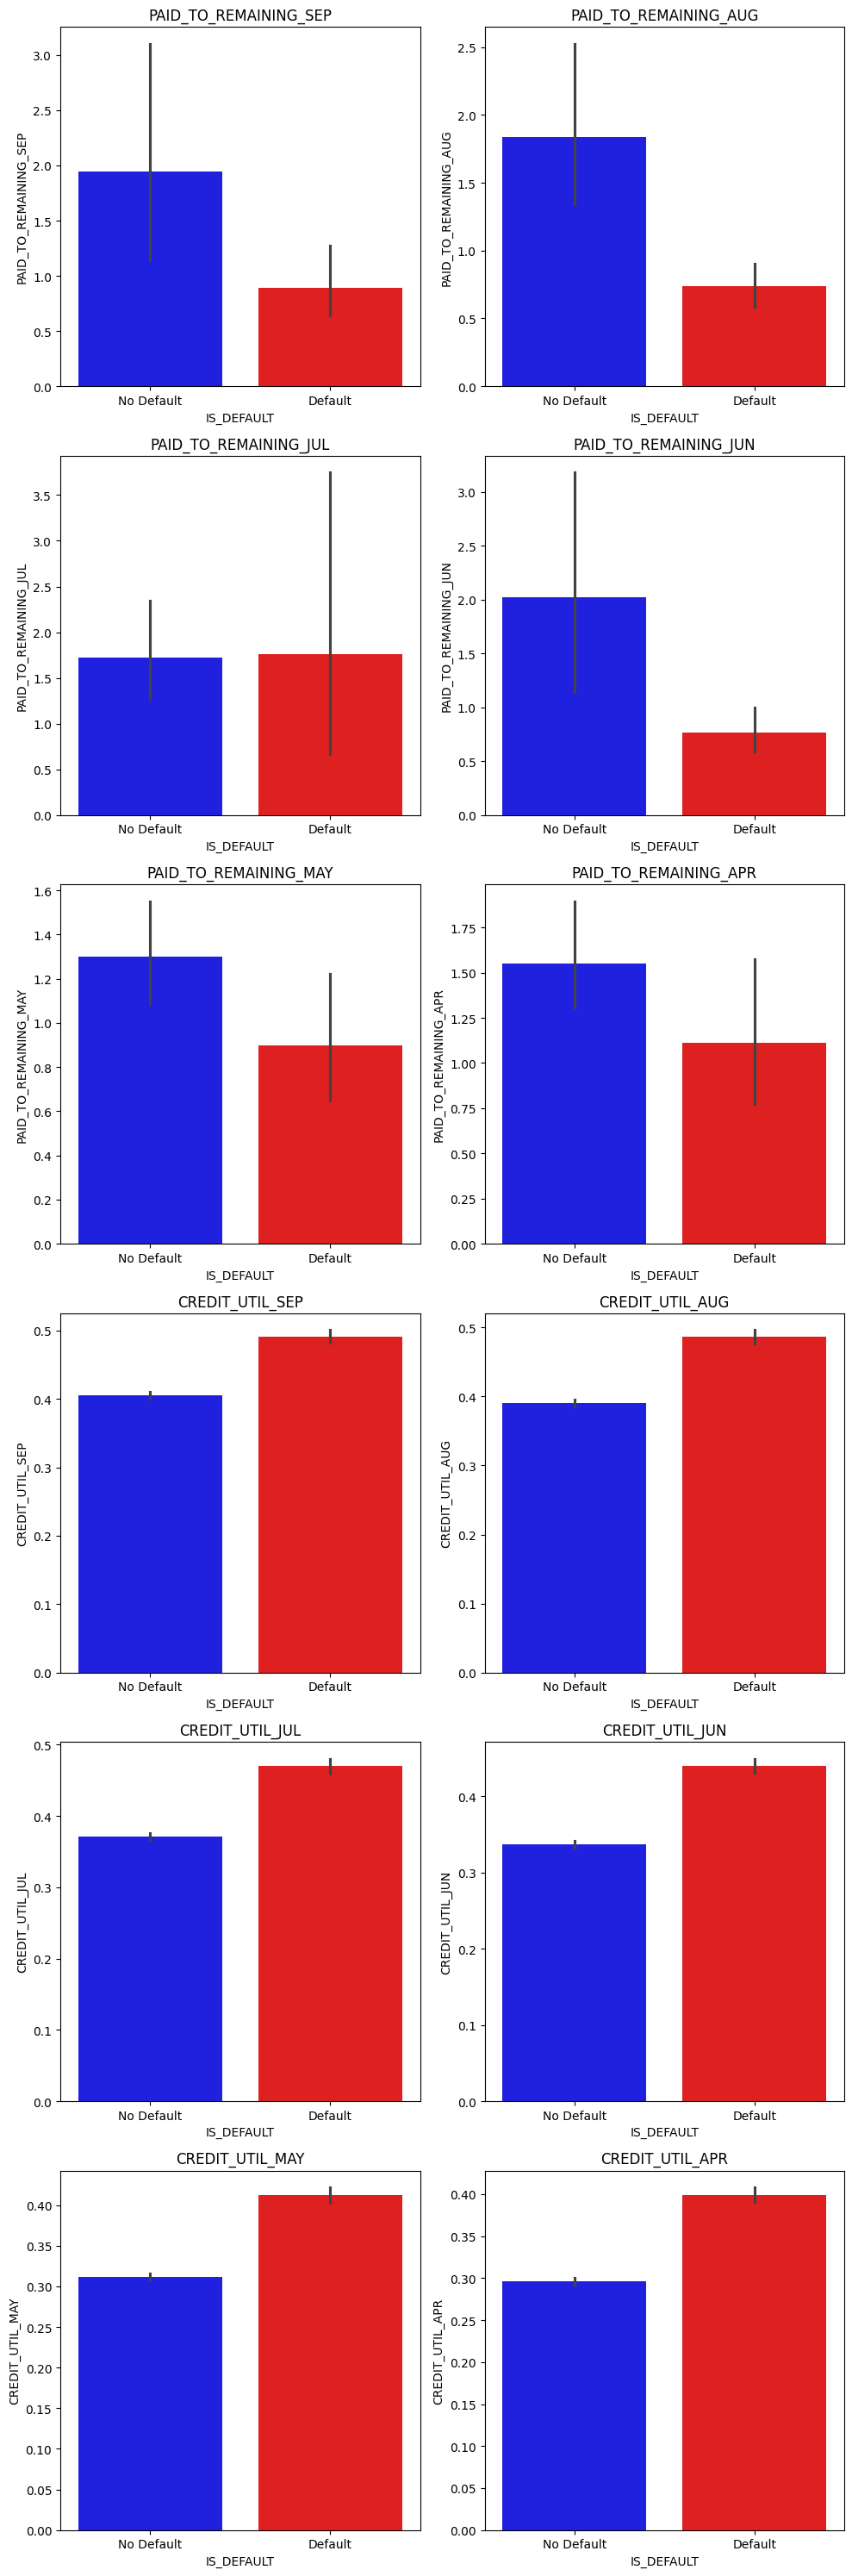

In [11]:
### MEAN FEATURE VALUE ACROSS TARGET CLASSES

fig, axes = plt.subplots(6, 2, figsize=(10, 30))
axes = axes.flatten()
plot_idx = 0

for col in input_cols:

    ax = axes[plot_idx]

    sns.barplot( # barplot for every feature, calculating mean for every target class
        data=df,
        hue=target_col,
        x=target_col,
        y=col,
        estimator="mean",
        ax=ax,
        palette=["blue", "red"],
        legend=False
    )

    ax.set_title(col)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No Default", "Default"])

    plot_idx += 1

# turn off remaining unused plots
for i in range(plot_idx, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

* `PAID_TO_REMAINING_*`: non-defaulting customers tend to cover more of their balances compared to defaulting ones
* `CREDIT_UTIL_*`: non-defaulting customers tend to utilize less of their available credit compared to defaulting ones

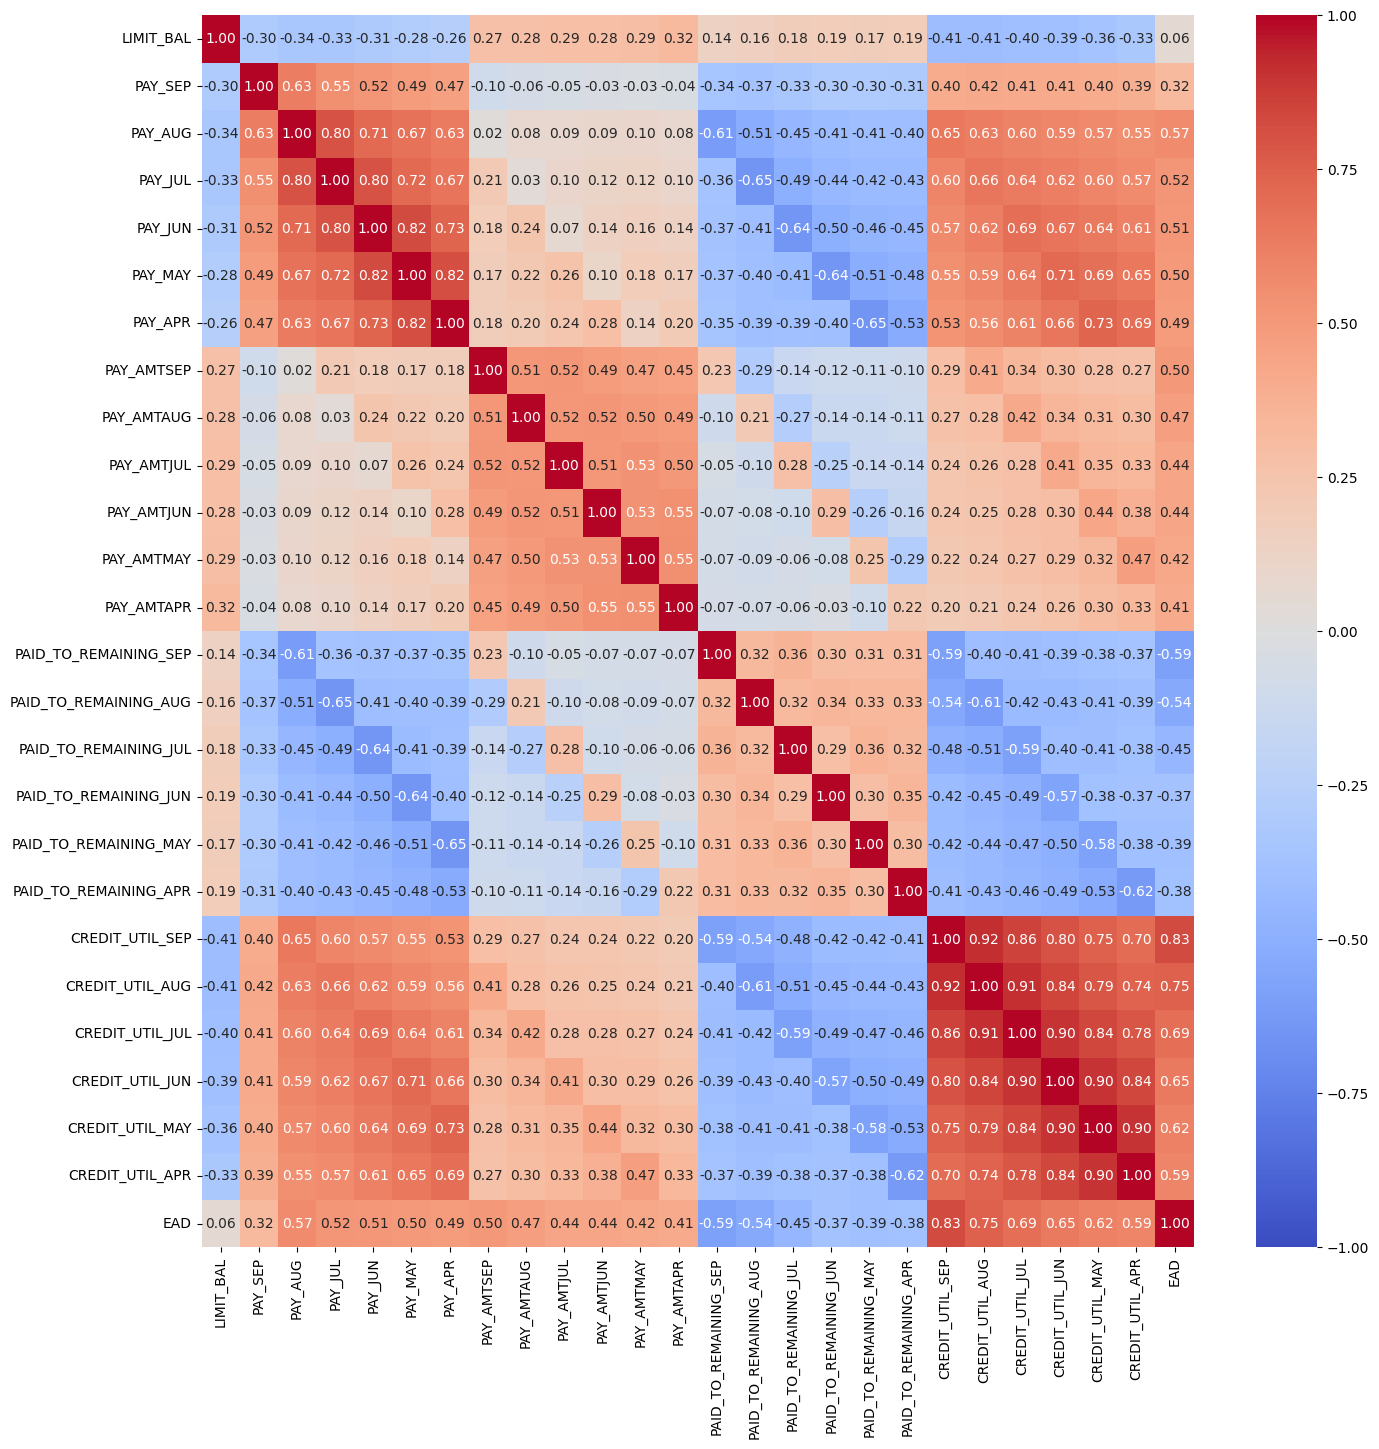

In [12]:
### CORRELATION HEATMAP

plt.figure(figsize=[16,16])

sns.heatmap(df.drop(columns=[target_col]).corr(method="spearman"), cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1) # spearman for skewed distributions and non-linear correlations

plt.show()

## 6. Second Feature engineering

From the last correlation heatmap it is clearly visible that `CREDIT_UTIL_*` variables feature strong multicollinearity. For this reason, another change is needed.

Two distinct features (`CREDIT_UTIL_MEAN` and `CREDIT_UTIL_TREND`) will be created:
* `CREDIT_UTIL_MEAN`: the arithmetic mean of total credit utilization features
* `CREDIT_UTIL_TREND`: the angular coefficient ($m$) of the regression line for `CREDIT_UTIL_*` data points. Represents credit utilization change over time
  
`PAID_TO_REMAINING_*` features do not suffer from severe multicollinearity. They provide near-independent predictive power, so no further engineering is needed

In [13]:
### DIMENSIONALITY REDUCTION on CREDIT_UTIL_*

credit_cols = [f"CREDIT_UTIL_{month}" for month in ["APR", "MAY", "JUN", "JUL", "AUG", "SEP"]]

df['CREDIT_UTIL_MEAN'] = df[credit_cols].mean(axis=1) 

# Calculate the angular coefficient of the CREDIT_UTIL trend over time -> m = cov(x,y) / var(x)
# m > 0 -> growing utilization, m < 0 -> shrinking utilization
x = np.array([1, 2, 3, 4, 5, 6])
x_mean = x.mean()
x_dev = x - x_mean
var_x = np.sum(x_dev ** 2)

df_centered = df[credit_cols].sub(df['CREDIT_UTIL_MEAN'], axis=0)
df['CREDIT_UTIL_TREND'] = (df_centered @ x_dev) / var_x

# Edit dataframe
df = df.drop(columns=credit_cols)

df.head()

,LIMIT_BAL,PAY_SEP,PAY_AUG,PAY_JUL,PAY_JUN,PAY_MAY,PAY_APR,PAY_AMTSEP,PAY_AMTAUG,PAY_AMTJUL,PAY_AMTJUN,PAY_AMTMAY,PAY_AMTAPR,IS_DEFAULT,PAID_TO_REMAINING_SEP,PAID_TO_REMAINING_AUG,PAID_TO_REMAINING_JUL,PAID_TO_REMAINING_JUN,PAID_TO_REMAINING_MAY,PAID_TO_REMAINING_APR,EAD,CREDIT_UTIL_MEAN,CREDIT_UTIL_TREND
0,620.0,2,2,-1,-1,-2,-2,0.000,21.359,0.0,0.0,0.000,0.000,1,0.000000,0.222115,0.000000,1.000000,1.000000,1.000000,121.303,0.064200,0.042229
1,3720.0,-1,2,0,0,0,2,0.000,31.000,31.0,31.0,0.000,62.000,1,0.000000,0.579710,0.372856,0.305623,0.000000,0.613309,83.142,0.023718,-0.002065
2,2790.0,0,0,0,0,0,0,47.058,46.500,31.0,31.0,31.000,155.000,0,0.051917,0.106937,0.073752,0.069779,0.066899,0.321564,906.409,0.188246,0.020608
3,1550.0,0,0,0,0,0,0,62.000,62.589,37.2,34.1,33.139,31.000,0,0.042562,0.041859,0.024345,0.038850,0.036914,0.033844,1456.690,0.771113,0.094865
4,1550.0,-1,0,-1,0,0,0,62.000,1137.111,310.0,279.0,21.359,21.049,0,0.232099,6.469312,0.279057,0.429799,0.035987,0.035492,267.127,0.364463,-0.044630


## 7. Third EDA (localized)

A confirming analysis will be made to validate the effectiveness of our new features. It is critical to verify residual multicollinearity structure and actual predictive power before proceeding

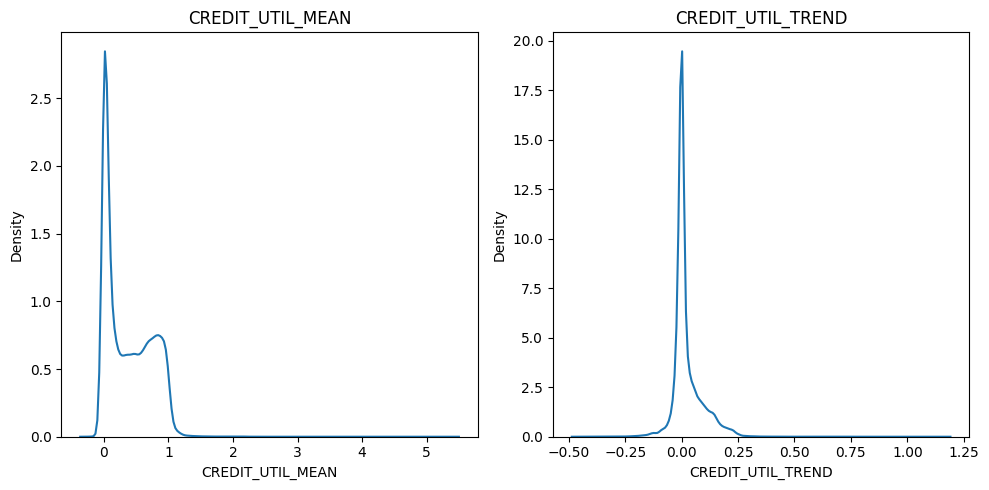

In [14]:
### PER-FEATURE DISTRIBUTION

input_cols = ["CREDIT_UTIL_MEAN", "CREDIT_UTIL_TREND"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes = axes.flatten()
plot_idx = 0

for col in input_cols:
    ax = axes[plot_idx]

    sns.kdeplot(data=df, x=col, ax=ax)

    ax.set_title(col)

    plot_idx += 1

# turn off remaining unused plots
for i in range(plot_idx, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


Same as month-per-month data: the mean has two modes close to $0$ and $1$, trend is also centered around $0$

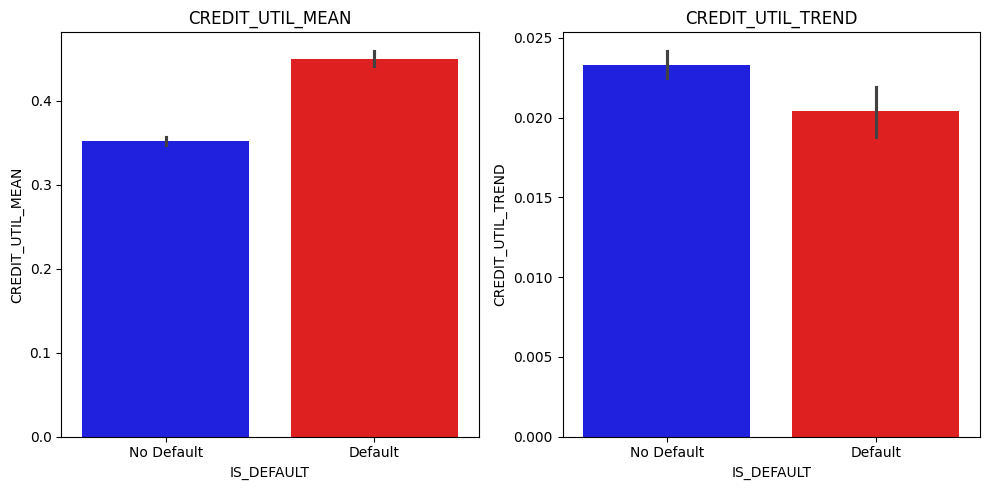

In [15]:
### MEAN FEATURE VALUE ACROSS TARGET CLASSES

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes = axes.flatten()
plot_idx = 0

for col in input_cols:

    ax = axes[plot_idx]

    sns.barplot( # barplot for every feature, calculating mean for every target class
        data=df,
        hue=target_col,
        x=target_col,
        y=col,
        estimator="mean",
        ax=ax,
        palette=["blue", "red"],
        legend=False
    )

    ax.set_title(col)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No Default", "Default"])

    plot_idx += 1

# turn off remaining unused plots
for i in range(plot_idx, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Similar as before: defaulting customers tend to utilize more of their limit while having a smaller change over time (trend)

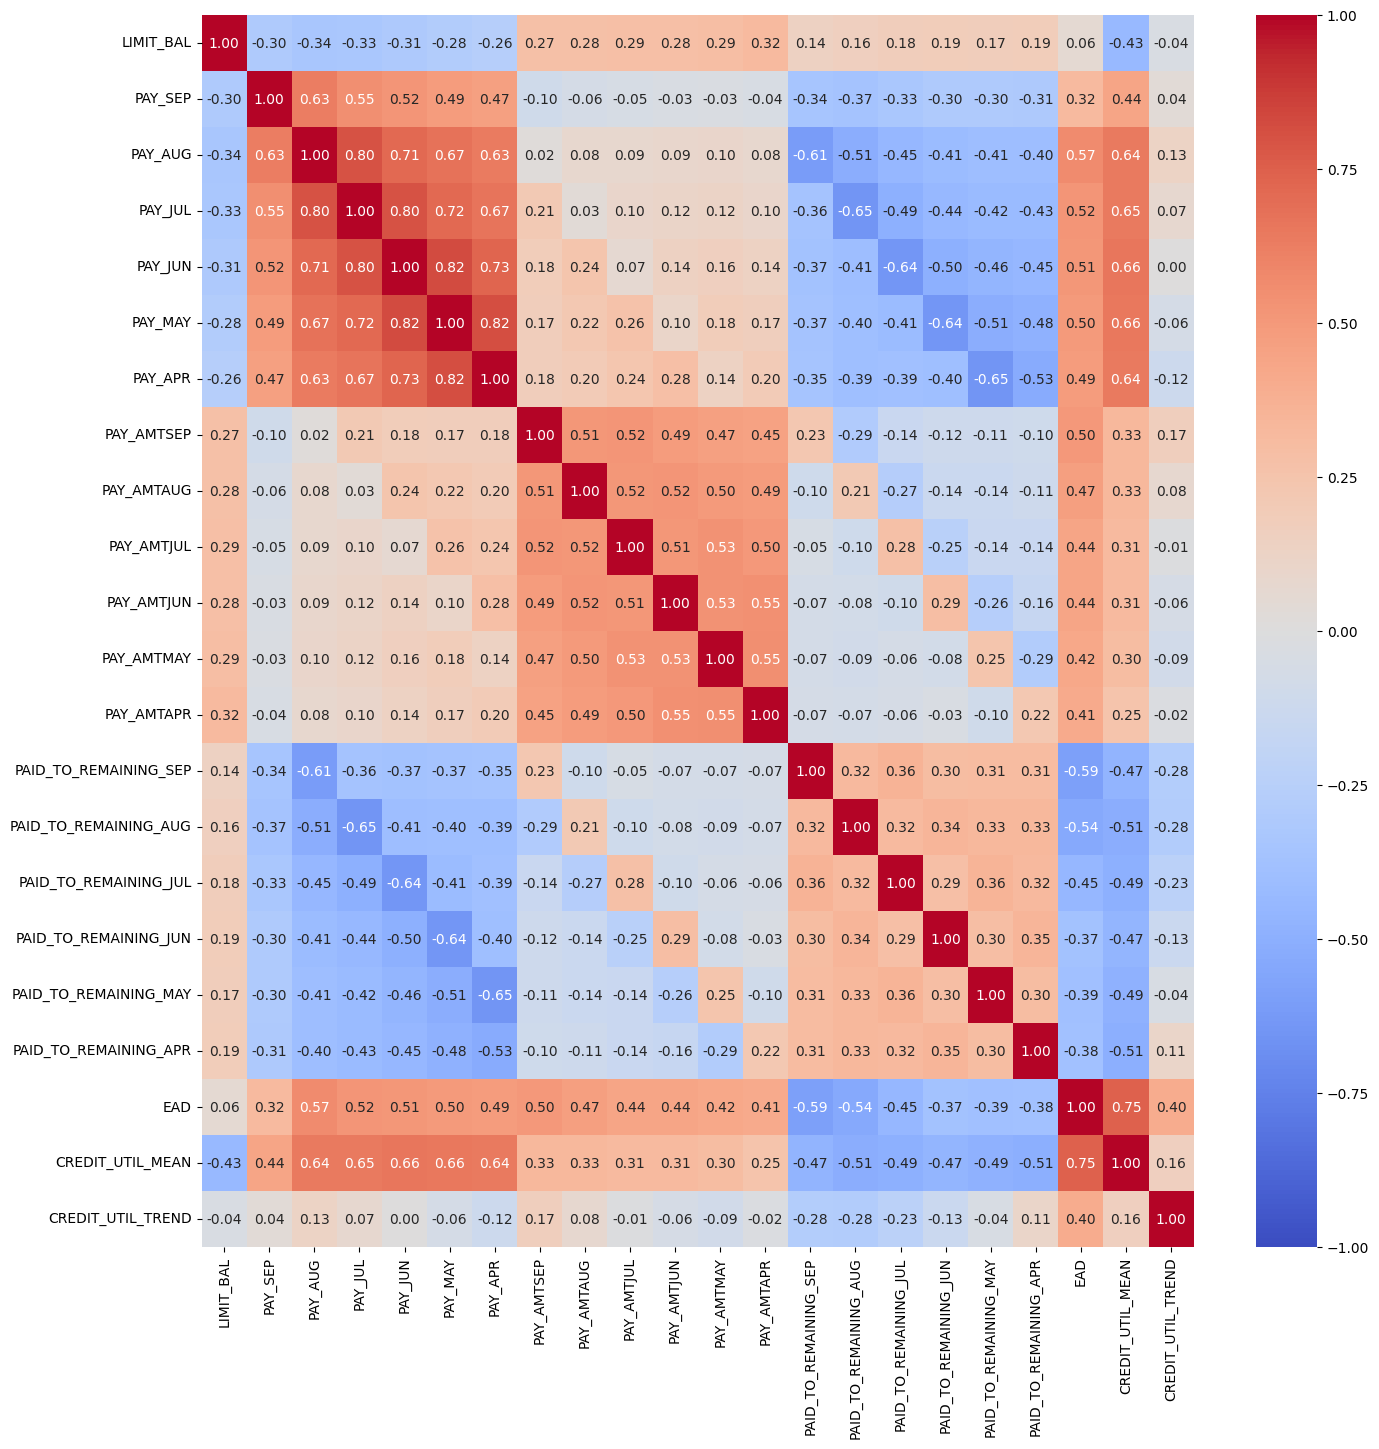

In [16]:
### CORRELATION HEATMAP

plt.figure(figsize=[16,16])

sns.heatmap(df.drop(columns=[target_col]).corr(method="spearman"), cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1) # spearman for skewed distributions and non-linear correlations

plt.show()

No evident multicollinearity is visible.

## 8. Saving

EDA and Feature Engineering are now fully complete. The feature space has been optimized by resolving localized multicollinearity and capturing temporal exposure trends

The next notebook, `03_Preprocessing_and_modeling.ipynb`, will focus on preparing the data for the modeling phase, with train/validation/test splitting and robust feature standardization, and constructing predictive models tailored to maximize our custom value-based economic metric.

In [17]:
df.to_csv("data/engineered.csv", index=False) # save the engineered dataframe to a new CSV file